In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sympy import *
from sympy.abc import t

In [4]:
b, ζ, ωₙ  = 10, 0.707, 4.0 
s = Symbol('s', complex=True)
P = Lambda(s, expand(1 / (s*(s+b)*(s + 2*ζ*ωₙ))))
P(s)

1/(s**3 + 15.656*s**2 + 56.56*s)

In [7]:
Kp, Ki, Kd = symbols('Kp Ki Kd', real=True, positive=True)
Ku = prod(Poly(denom(P(s)),s,domain='CC').all_coeffs()[:-1])
Ku

885.503360000000

In [ ]:
def feedback_pid(s,P, pid_params):
    Kp, Ki, Kd = pid_params
    C = Lambda(s,Kp + Ki/s + Kd*s)
    L = C(s)*P(s)
    return simplify(L/(1+L))

In [17]:
T1 = feedback_pid(s,P,[Ku, 0, 0])
T1

885.50336/(s**3 + 15.656*s**2 + 56.56*s + 885.50336)

In [10]:
def plot_response(y,tmax,plot_attrs=dict()):
    tt = np.linspace(0, tmax, 512)
    fig = plt.figure(figsize=plot_attrs.get('figsize',(6,3)))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(tt,y(tt).real, label=plot_attrs.get('label',r'$y(t)$')) 
    ax.set_title(plot_attrs.get('title','Step Response'))
    ax.set_ylabel(plot_attrs.get('ylabel',r'$y(t)$'))
    ax.set_xlabel(plot_attrs.get('xlabel','Time (s)'))
    if plot_attrs.get('grid',True):
        ax.grid(True)
    ax.legend()

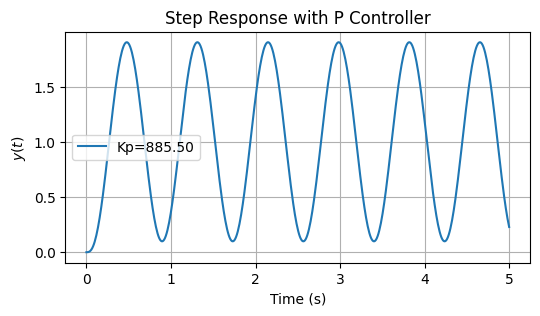

In [18]:
y = lambdify(t, simplify(inverse_laplace_transform(T1/s, s, t)),'numpy')
plot_response(y, 5,{'title':'Step Response with P Controller', 'label':f'Kp={round(Ku,2)}'})

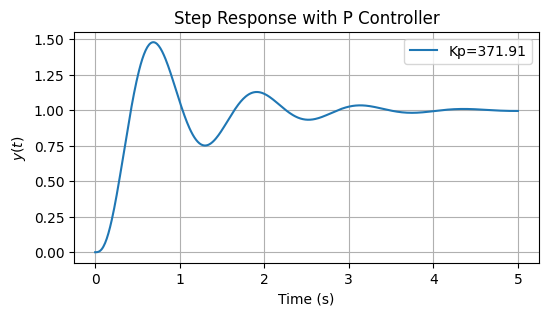

In [14]:
kp = 0.42*Ku
T1 = feedback_pid(s,P, [kp, 0, 0])
y = lambdify(t, simplify(inverse_laplace_transform(T1/s, s, t)),'numpy')
plot_response(y, 5,{'title':'Step Response with P Controller', 'label':f'Kp={round(kp,2)}'})

In [19]:
T2 = feedback_pid(s,P,[kp,0, Kd])
T2


(Kd*s + 371.9114112)/(Kd*s + s**3 + 15.656*s**2 + 56.56*s + 371.9114112)

In [20]:
roots(numer(T2),s)

{-371.9114112/Kd: 1}

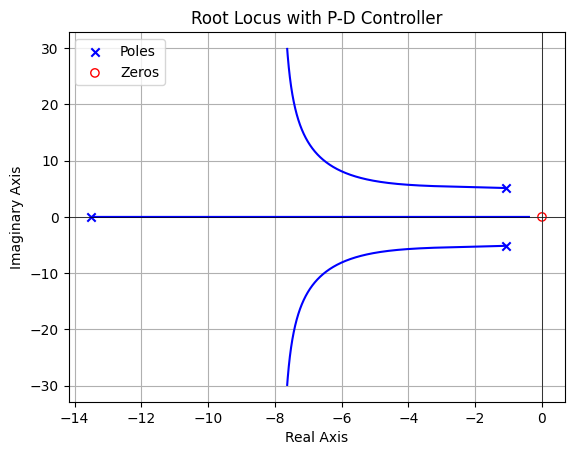

In [23]:
q = denom(T2)
rl = list(roots(q,s).keys())
ps = np.array([r.subs(Kd,0) for r in rl],dtype=complex)
locis = [lambdify(Kd,simplify(r),'numpy') for r in rl]
for loci in locis:
    gains = np.linspace(0,900,4096)
    s_vals = loci(gains)
    plt.plot(s_vals.real, s_vals.imag,color='blue',lw=1.5)

plt.title('Root Locus with P-D Controller')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.grid(True)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.scatter(ps.real, ps.imag, marker='x', color='blue', label='Poles')
plt.scatter([0], [0], marker='o',fc='none', color='red', label='Zeros')
plt.legend()

In [37]:
kd = 75
T2 = feedback_pid(s,P,[kp,0, kd])
T2

(75*s + 371.9114112)/(s**3 + 15.656*s**2 + 131.56*s + 371.9114112)

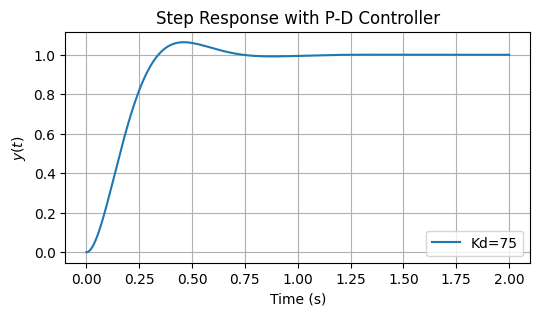

In [36]:
y = lambdify(t, simplify(inverse_laplace_transform(T2/s, s, t)),'numpy')
plot_response(y, 2,{'title':'Step Response with P-D Controller', 'label':f'Kd={75}'})

In [65]:
T3 = feedback_pid(s,P,[kp, Ki, 0])
T3

(Ki + 371.9114112*s)/(Ki + s**2*(s**2 + 15.656*s + 56.56) + 371.9114112*s)

In [41]:
roots(numer(T3).subs(Ki,0),s)

{-4.95881881600000: 1, 0: 1}

In [66]:
q = denom(T3)
ps = np.array(list(roots(q.subs(Ki,0),s).keys()),dtype=complex)
zs = np.array(list(roots(numer(T3).subs(Ki,0),s).keys()),dtype=complex)
rl = [solve(q.subs(Ki,A),s) for A in np.linspace(0,500,512)]

In [67]:
rl = np.array(rl,dtype=complex)

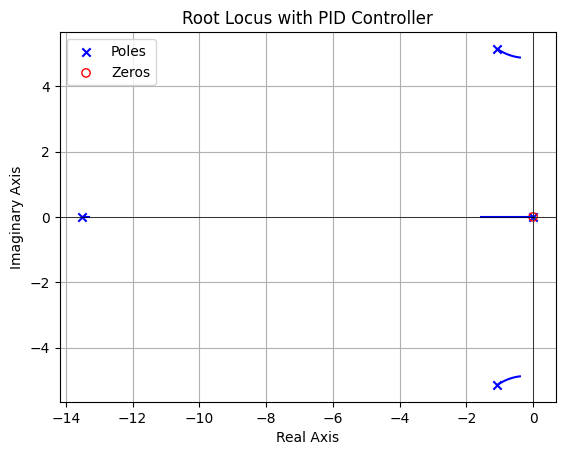

In [68]:

for k in range(rl.shape[1]):
    plt.plot(rl[:,k].real, rl[:,k].imag,color='blue',lw=1.5)  


plt.title('Root Locus with PID Controller')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.grid(True)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.scatter(ps.real, ps.imag, marker='x', color='blue', label='Poles')
plt.scatter(zs.real, zs.imag, marker='o',fc='none', color='red', label='Zeros')
plt.legend()